In [21]:
import random
from copy import deepcopy

import numpy as np
import pandas as pd
import torch
from sklearn.metrics import accuracy_score
from torch import nn
from torch.utils.data import DataLoader, TensorDataset


import itertools
import json
import os
import random
import re
import subprocess
from string import punctuation

import gensim.matutils
import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import pymorphy2
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import wget
from gensim.models import FastText, KeyedVectors, Word2Vec
from nltk.corpus import stopwords
from nltk.stem.snowball import SnowballStemmer
from nltk.tokenize import word_tokenize
from pymorphy2 import MorphAnalyzer
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from ufal.udpipe import Model, Pipeline

In [22]:
# reproducibility
RANDON_STATE = 42
random.seed(RANDON_STATE)
np.random.seed(RANDON_STATE)
torch.manual_seed(RANDON_STATE)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [23]:
device

device(type='cuda')

In [24]:
def make_loader(X: np.ndarray, y: np.ndarray, batch_size: int = 64, *, shuffle=False):
    """Wrap numpy arrays into a PyTorch DataLoader."""
    X_t = torch.as_tensor(X, dtype=torch.float32)
    y_t = torch.as_tensor(y, dtype=torch.long)
    return DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, shuffle=shuffle)


def build_ff(in_dim: int, hidden_dims: list[int], *, num_classes: int = 2) -> nn.Module:
    """Dynamically build a feed‑forward classifier."""
    layers: list[nn.Module] = []
    for h in hidden_dims:
        layers.extend([nn.Linear(in_dim, h), nn.ReLU()])
        in_dim = h
    layers.append(nn.Linear(in_dim, num_classes))
    return nn.Sequential(*layers)

In [54]:
def train_model(model, train_loader, val_loader, *, lr=1e-3, epochs=10):
    model.to(device)
    optim = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    best_acc, best_state = 0.0, None
    history = {'train_acc': [], 'val_acc': []}

    for _ in range(epochs):
        # Train
        model.train()
        correct, total = 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optim.zero_grad()
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()
            optim.step()
            pred = logits.argmax(1)
            correct += (pred == yb).sum().item()
            total += yb.size(0)
        history['train_acc'].append(correct / total)

        # Validation
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                logits = model(xb.to(device))
                pred = logits.argmax(1).cpu()
                correct += (pred == yb).sum().item()
                total += yb.size(0)
        acc = correct / total
        history['val_acc'].append(acc)
        if acc > best_acc:
            best_acc = acc
            best_state = model.state_dict()

    model.load_state_dict(best_state)
    return best_acc, model, history


In [36]:
df = pd.read_csv("tokenormalized.csv")

df = df[df["type"].isin([-1, 0])].copy()
df["type"] = df["type"] + 1

X_train, X_test, y_train, y_test = train_test_split(
    df["tokens"], df["type"], test_size=0.2, random_state=RANDON_STATE
)

In [37]:
y_train = np.array(y_train, dtype=int)
y_test = np.array(y_test, dtype=int)

In [40]:
word2vec_model = Word2Vec(
    sentences=df["tokens"], vector_size=100, window=5, min_count=1, workers=4
)


def get_word2vec_features(tokens, model, vector_size=100):
    vectors = [model.wv[word] for word in tokens if word in model.wv]

    return np.mean(vectors, axis=0) if vectors else np.zeros(vector_size)


X_train_w2v = np.array(
    [get_word2vec_features(tokens, word2vec_model) for tokens in X_train]
)
X_test_w2v = np.array(
    [get_word2vec_features(tokens, word2vec_model) for tokens in X_test]
)
X_train_w2v_sub, X_val_w2v, y_train_sub, y_val = train_test_split(
    X_train_w2v, y_train, test_size=0.2, stratify=y_train, random_state=RANDON_STATE
)

In [41]:
fasttext_model = FastText(
    sentences=df["tokens"], vector_size=100, window=5, min_count=1, workers=4
)


def get_fasttext_features(tokens, model, vector_size=100):
    vectors = [model.wv[word] for word in tokens if word in model.wv]

    return np.mean(vectors, axis=0) if vectors else np.zeros(vector_size)


X_train_ft = np.array(
    [get_fasttext_features(tokens, fasttext_model) for tokens in X_train]
)
X_test_ft = np.array(
    [get_fasttext_features(tokens, fasttext_model) for tokens in X_test]
)
X_train_ft_sub, X_val_ft, _, _ = train_test_split(
    X_train_ft, y_train, test_size=0.2, stratify=y_train, random_state=RANDON_STATE
)

In [42]:
y_train = np.array(y_train, dtype=int)
y_test = np.array(y_test, dtype=int)
y_val = np.array(y_val, dtype=int)

In [43]:
print("y_train unique:", np.unique(y_train))
print("y_test  unique:", np.unique(y_test))
print("y_val  unique:", np.unique(y_val))

print("y_train min/max:", np.min(y_train), np.max(y_train))

print("dtype:", y_train.dtype)

y_train unique: [0 1]
y_test  unique: [0 1]
y_val  unique: [0 1]
y_train min/max: 0 1
dtype: int32


In [44]:
train_loader_w2v = make_loader(X_train_w2v_sub, y_train_sub, shuffle=True)
test_loader_w2v = make_loader(X_test_w2v, y_test)
val_loader_w2v = make_loader(X_val_w2v, y_val)

train_loader_ft = make_loader(X_train_ft_sub, y_train_sub, shuffle=True)
test_loader_ft = make_loader(X_test_ft, y_test)
val_loader_ft = make_loader(X_val_ft, y_val)

In [45]:
device = torch.device("cpu")
device

device(type='cpu')

In [48]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [55]:
hidden_sets = [[64], [128, 64], [256, 128, 64]]
lr_vals = [0.001, 0.0003]
results = []

all_histories = {}

for hidden in hidden_sets:
    for lr in lr_vals:
        # Word2Vec
        model = build_ff(100, hidden, num_classes=2)
        best_acc, best_model, hist = train_model(
            model, train_loader_w2v, val_loader_w2v, lr=lr
        )
        all_histories[f"W2V_{hidden}_{lr}"] = hist
        # test
        best_model.eval()
        preds = []
        trues = []
        with torch.no_grad():
            for xb, yb in test_loader_w2v:
                logits = best_model(xb.to(device))
                preds.extend(logits.argmax(1).cpu().numpy())
                trues.extend(yb.numpy())
        acc = accuracy_score(trues, preds)
        f1 = f1_score(trues, preds)
        results.append(
            {
                "vec": "Word2Vec",
                "layers": len(hidden),
                "neurons": "-".join(map(str, hidden)),
                "lr": lr,
                "test_acc": acc,
                "test_f1": f1,
            }
        )

        # FastText
        model = build_ff(100, hidden, num_classes=2)
        best_acc, best_model, hist = train_model(
            model, train_loader_ft, val_loader_ft, lr=lr
        )
        all_histories[f"FT_{hidden}_{lr}"] = hist
        best_model.eval()
        preds = []
        trues = []
        with torch.no_grad():
            for xb, yb in test_loader_ft:
                logits = best_model(xb.to(device))
                preds.extend(logits.argmax(1).cpu().numpy())
                trues.extend(yb.numpy())
        acc = accuracy_score(trues, preds)
        f1 = f1_score(trues, preds)
        results.append(
            {
                "vec": "FastText",
                "layers": len(hidden),
                "neurons": "-".join(map(str, hidden)),
                "lr": lr,
                "test_acc": acc,
                "test_f1": f1,
            }
        )

In [56]:
results_df = (
    pd.DataFrame(results)
    .sort_values("test_acc", ascending=False)
    .reset_index(drop=True)
)
results_df.head(10)

,vec,layers,neurons,lr,test_acc,test_f1
0,FastText,2,128-64,0.0010,0.501608,0.668095
1,FastText,1,64,0.0010,0.501564,0.667996
2,FastText,2,128-64,0.0003,0.501541,0.667897
3,FastText,1,64,0.0003,0.501519,0.667917
4,Word2Vec,3,256-128-64,0.0003,0.498593,0.031913
5,Word2Vec,1,64,0.0010,0.498369,0.000000
6,Word2Vec,1,64,0.0003,0.498369,0.000801
7,Word2Vec,2,128-64,0.0010,0.498369,0.000000
8,Word2Vec,3,256-128-64,0.0010,0.498369,0.000000
9,FastText,3,256-128-64,0.0010,0.498369,0.000000


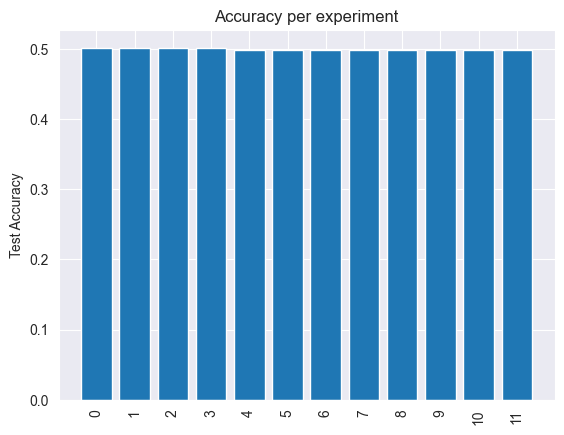

In [57]:
plt.figure()
plt.bar(results_df.index.astype(str), results_df['test_acc'])
plt.xticks(rotation=90)
plt.ylabel('Test Accuracy')
plt.title('Accuracy per experiment')
plt.show()

Best run: W2V_[64]_0.0003


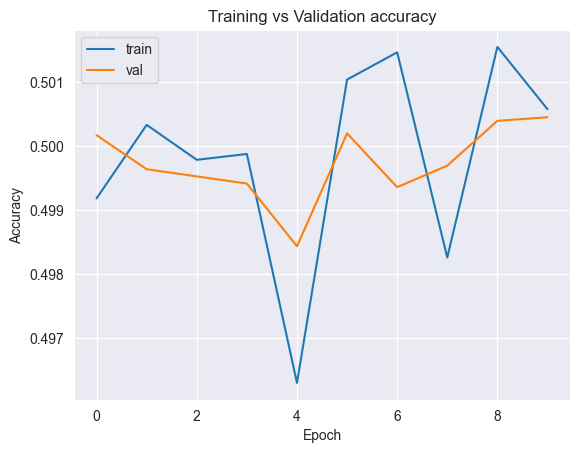

In [58]:
best_key = max(all_histories, key=lambda k: all_histories[k]['val_acc'][-1])
print('Best run:', best_key)
hist = all_histories[best_key]
plt.figure()
plt.plot(hist['train_acc'], label='train')
plt.plot(hist['val_acc'], label='val')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.title('Training vs Validation accuracy')
plt.legend()
plt.show()